# Processing with OCSSW Command Line Interface (CLI)

**Authors:** Carina Poulin (NASA, SSAI), Ian Carroll (NASA, UMBC), Anna Windle (NASA, SSAI)

<div class="alert alert-success" role="alert">

The following notebooks are **prerequisites** for this tutorial.

- Learn with OCI: [Data Access][oci-data-access]
- Learn with OCI: [Installing and Running OCSSW Command-line Tools][ocssw_install]

</div>

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data.

</div>

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[ocssw_install]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_ocssw_install/

## Summary

[SeaDAS][seadas] is the official data analysis sofware of NASA's Ocean Biology Distributed Active Archive Center (OB.DAAC); used to process, display and analyse ocean color data. SeaDAS is a dektop application that includes the Ocean Color Science Software (OCSSW) libraries. There is also a command line interface (CLI) for the OCSSW libraries, which we can use to write processing scripts and notebooks without SeaDAS.

This tutorial will show you how to process PACE OCI data using the sequence of OCSSW programs `l2gen`, `l2bin`, and `l3mapgen`.

[seadas]: https://seadas.gsfc.nasa.gov/

## Learning Objectives

At the end of this notebok you will know:
* How to process Level-1B (L1B) data to Level-2 (L2) with `l2gen`
* How to merge two images with `l2bin`
* How to create a map with `l3mapgen`

## Contents

1. [Setup](#1.-Setup)
2. [Get L1B Data](#2.-Get-L1B-Data)
3. [Process L1B Data with `l2gen`](#3.-Process-L1B-Data-with-l2gen)
4. [Composite L2 Data with `l2bin`](#4.-Composite-L2-Data-with-l2bin)
5. [Make a Map from Binned Data with `l3mapgen`](#5.-Make-a-Map-from-Binned-Data-with-l3mapgen)

## 1. Setup

Begin by importing all of the packages used in this notebook. If your kernel uses an environment defined following the guidance on the [tutorials] page, then the imports will be successful.

[tutorials]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/

In [1]:
import csv
import os
from pathlib import Path

import cartopy.crs as ccrs
import earthaccess
import matplotlib.pyplot as plt
import xarray as xr

We are also going to define a function to help write OCSSW parameter files, which
is needed several times in this tutorial. To write the results in the format understood
by OCSSW, this function uses the `csv.writer` from the Python Standard Library. Instead of
writing comma-separated values, however, we specify a non-default delimiter to get
equals-separated values. Not something you usually see in a data file, but it's better than
writing our own utility from scratch!

In [2]:
def write_par(path, par):
    """Prepare a parameter file to be read by one of the OCSSW tools.

    Using a parameter file (a.k.a. "par file") is equivalent to specifying
    parameters on the command line.

    Parameters
    ----------
    path
        where to write the parameter file
    par
        the parameter names and values included in the file
    """
    with open(path, "w") as file:
        writer = csv.writer(file, delimiter="=")
        writer.writerows(par.items())

The Python docstring (fenced by triple quotation marks in the function definition) is not
essential, but it helps describe what the function does.
This docstring follows the NumPy [style guide], which is one of a few common conventions.

[style guide]: https://numpydoc.readthedocs.io/

In [3]:
help(write_par)

Help on function write_par in module __main__:

write_par(path, par)
    Prepare a parameter file to be read by one of the OCSSW tools.
    
    Using a parameter file (a.k.a. "par file") is equivalent to specifying
    parameters on the command line.
    
    Parameters
    ----------
    path
        where to write the parameter file
    par
        the parameter names and values included in the file



[back to top](#Contents)

## 2. Get L1B Data


Set (and persist to your user profile on the host, if needed) your Earthdata Login credentials.

In [4]:
auth = earthaccess.login(persist=True)

To use OCSSW cloud processing, we also need to set our temporary S3 credentials.

In [5]:
credentials = earthaccess.get_s3_credentials(provider="OB_CLOUD")

We will use the `earthaccess` search method used in the OCI Data Access notebook. Note that Level-1B (L1B) files
do not include cloud coverage metadata, so we cannot use that filter. In this search, the spatial filter is
performed on a location given as a point represented by a tuple of latitude and longitude in decimal degrees.

In [6]:
tspan = ("2024-04-27", "2024-04-27")
location = (-56.5, 49.8)

The `search_data` method accepts a `point` argument for this type of location.

In [7]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L1B_SCI",
    temporal=tspan,
    point=location,
)
results[0]

Collection: {'Version': '3', 'ShortName': 'PACE_OCI_L1B_SCI'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 58.6251, 'Longitude': -40.61246}, {'Latitude': 51.73084, 'Longitude': -82.26333}, {'Latitude': 35.25084, 'Longitude': -70.53031}, {'Latitude': 40.88992, 'Longitude': -40.48577}, {'Latitude': 58.6251, 'Longitude': -40.61246}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2024-04-27T16:21:53Z', 'BeginningDateTime': '2024-04-27T16:16:54Z'}}
Size(MB): 1723.1885194778442
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240427T161654.L1B.V3.nc']

Store the link to the data in a variable for future use.

In [8]:
ifile = results[0].data_links(access="direct")[0]
ifile

's3://ob-cumulus-prod-public/PACE_OCI.20240427T161654.L1B.V3.nc'

The L1B files contain top-of-atmosphere reflectances, typically denoted as $\rho_t$.
On OCI, the reflectances are grouped into blue, red, and short-wave infrared (SWIR) wavelengths. Open
the dataset's "observation_data" group in the netCDF file using `xarray` to plot a "rhot_red"
wavelength.

In [9]:
f = earthaccess.open([ifile], provider="OB_CLOUD")

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

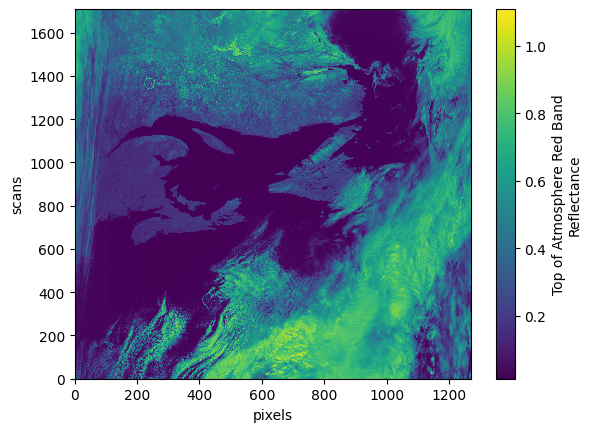

In [10]:
dataset = xr.open_dataset(f[0], group="observation_data")
plot = dataset["rhot_red"][dict(red_bands=100)].plot()

[back to top](#Contents)

## 3. Process L1B Data with `l2gen`

At Level-1, we neither have geophysical variables nor are the data projected for easy map making. We will need to process the L1B file to L2 and then to Level-3-Mapped (L3M) to get both of those. Note that L2 data for many geophysical variables are available for download from the OB.DAAC, so you often don't need the first step. However, the L3M data distributed by the OB.DAAC are global composites, which may cover more L2 scenes than you want. You'll learn more about compositing below. This section shows how to use `l2gen` for processing the L1B data to L2 using customizable parameters.

<div class="alert alert-warning">

OCSSW programs are system commands, typically called in a Bash shell. We will employ [system shell access][ipython] available in the IPython kernel to launch system commands as a subprocess using the `!` prefix. In the specific case of OCSSW programs, a suite of required environment variables must be set by first executing `source $OCSSWROOT/OCSSW_bash.env` in the same subprocess.

</div>

Every time we use `!` to invoke an OCSSW program, we must also evaluate the `OCSSW_bash.env` environment file shipped with OCSSW. Each `!` initiated subprocess is distinct, and the environment configuration is discarded after the command is finished. Let's get prepared by reading the path to the OCSSW installation from the `OCSSWROOT` environment variable (assuming it's `/tmp/ocssw` as a fallback).

[ipython]: https://ipython.readthedocs.io/en/stable/interactive/reference.html#system-shell-access

In [11]:
ocsswroot = os.environ.setdefault("OCSSWROOT", "/tmp/ocssw")
env = Path(ocsswroot, "OCSSW_bash.env")
env.exists()

True

We then neet to set up the AWS cloud processing credentials in our environment.

In [12]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": credentials["accessKeyId"],
        "AWS_SECRET_ACCESS_KEY": credentials["secretAccessKey"],
        "AWS_SESSION_TOKEN": credentials["sessionToken"],
    }
)

Then we need a couple lines, which will appear in multiple cells below, to begin a Bash cell initiated with the `OCSSW_bash.env` file.

Using this pattern, run the `l2gen` command with the single argument `help` to view the extensive list of options available. You can find more information about `l2gen` and other OCSSW functions on the [seadas website](https://seadas.gsfc.nasa.gov/help-8.3.0/processors/ProcessL2gen.html)

In [13]:
!source {env}; l2gen help

msl12 9.11.0-V2025.2 (Jul 28 2025 22:16:10)
Usage: msl12 argument-list

  The argument-list is a set of keyword=value pairs. The arguments can
  be specified on the commandline, or put into a parameter file, or the
  two methods can be used together, with commandline over-riding.

  return value: 0=OK, 1=error, 110=north,south,east,west does not intersect
  file data.

The list of valid keywords follows:

   help (boolean) (alias=h) (default=false) = print usage information
   version (boolean) (default=false) = print the version
        information
   dump_options (boolean) (default=false) = print
        information about each option
   dump_options_paramfile (ofile) = print
        information about each option to paramfile
   dump_options_xmlfile (ofile) = print
        information about each option to XML file
   par (ifile) = input parameter file
   pversion (string) (default=Unspecified) = processing version string
   suite (string) (default=OC) = product suite string for loadin

To process a L1B file using `l2gen`, at a minimum, you need to set an infile name (`ifile`) and an outfile name (`ofile`). You can also indicate a data suite or L2 products; in this example, we will proceed with chlorophyll *a* estimates.

Parameters can be passed to OCSSW programs through a text file. They can also be passed as arguments, but writing to a text file leaves a clear processing record. Define the parameters in a dictionary, then send it to the `write_par` function
defined in the [Setup](#1.-Setup) section.

We can limit the geographical boundaries of the processing. Here we use the `location` variable to set Northwestern and Southeastern boundaries.

In [14]:
location = [(-62, 49), (-60, 47)]
par = {
    "ifile": ifile,
    "ofile": os.path.basename(ifile).replace("L1B", "L2"),
    "l2prod": "chlor_a",
    "proc_uncertainty": 0,
    "north": location[0][1],
    "south": location[1][1],
    "east": location[1][0],
    "west": location[0][0],
}
write_par("l2gen.par", par)

With the parameter file ready, it's time to call `l2gen` from a `%%bash` cell.

In [15]:
!source {env}; l2gen par=l2gen.par

Loading default parameters from /opt/ocssw/share/common/msl12_defaults.par


Input file s3://ob-cumulus-prod-public/PACE_OCI.20240427T161654.L1B.V3.nc is PACE L1B file.

Loading characteristics for OCI
Opening sensor information file /opt/ocssw/share/oci/msl12_sensor_info.dat


  Bnd   Lam       Fo    Tau_r     k_oz    k_no2    t_co2   awhite       aw      bbw
    0  314.550  112.329 4.880e-01 4.222e-01 3.282e-19 1.000e+00 0.000e+00 2.305e-01 6.356e-03
    1  316.239   92.673 6.491e-01 5.817e-01 2.960e-19 1.000e+00 0.000e+00 1.633e-01 7.727e-03
    2  318.262   85.208 7.410e-01 5.479e-01 2.844e-19 1.000e+00 0.000e+00 1.278e-01 8.187e-03
    3  320.303   82.100 7.807e-01 4.616e-01 2.833e-19 1.000e+00 0.000e+00 1.105e-01 8.271e-03
    4  322.433   80.692 7.906e-01 3.551e-01 2.898e-19 1.000e+00 0.000e+00 9.950e-02 8.190e-03
    5  324.649   86.329 7.916e-01 2.573e-01 3.019e-19 1.000e+00 0.000e+00 9.079e-02 8.041e-03
    6  326.828   95.925 7.891e-01 1.911e-01 3.132e-19 1.000e+00 0.000e+00 8.475e-02 7.871e-03
    7  328.988  101.478 7.699e-01 1.387e-01 3.251e-19 1.000e+00 0.000e+00 8.211e-02 7.627e-03
    8  331.305  101.788 7.403e-01 9.848e-02 3.418e-19 1.000e+00 0.000e+00 8.089e-02 7.342e-03
    9  333.958   98.128 7.205e-01 6.838e-02 3.572e-19 1.000e+00 0.000e

Loading gain and offset from calfile: /opt/ocssw/share/oci/cal/oci_gains_v3.1_20250722.nc


OCI L1B Npix  :1272 Nlines:1710


...

Processing scan #   924 (101 of 211) after     41 seconds


Processing scan #   974 (151 of 211) after     55 seconds


Processing scan #  1024 (201 of 211) after     71 seconds



Percentage of pixels flagged:
Flag # 1:          ATMFAIL          0   0.0000
Flag # 2:             LAND        310   0.8542
Flag # 3:         PRODWARN          0   0.0000
Flag # 4:          HIGLINT          0   0.0000
Flag # 5:             HILT          0   0.0000
Flag # 6:         HISATZEN          0   0.0000
Flag # 7:           COASTZ       2107   5.8057
Flag # 8:            SPARE          0   0.0000
Flag # 9:       STRAYLIGHT        685   1.8875
Flag #10:           CLDICE        511   1.4080
Flag #11:        COCCOLITH          7   0.0193
Flag #12:          TURBIDW        132   0.3637
Flag #13:         HISOLZEN          0   0.0000
Flag #14:            SPARE          0   0.0000
Flag #15:            LOWLW        239   0.6585
Flag #16:          CHLFAIL          3   0.0083
Flag #17:          NAVWARN          0   0.0000
Flag #18:           ABSAER          0   0.0000
Flag #19:            SPARE          0   0.0000
Flag #20:       MAXAERITER          5   0.0138
Flag #21:         MODGLINT   


Processing Completed


If successful, the `l2gen` program created a netCDF file at the `ofile` path.
The contents should include the `rhos` product from the `SFREFL` suite of products and be cropped to a small bounding box.
Once this process is done, you are ready to visualize your "custom" L2 data.
Use the `robust=True` option to ignore outlier values.

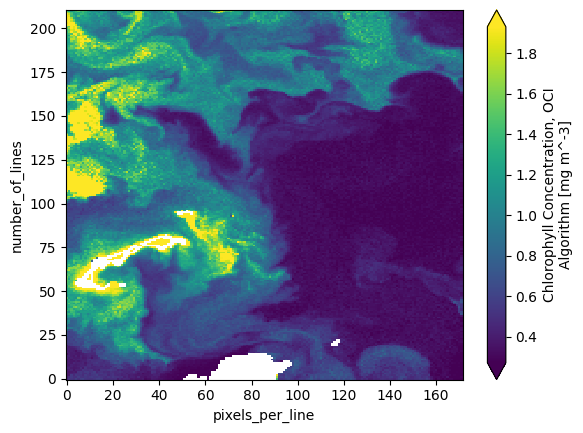

In [16]:
dataset = xr.open_dataset(par["ofile"], group="geophysical_data")
plot = dataset["chlor_a"].plot(cmap="viridis", robust=True)

Feel free to explore `l2gen` options to produce the L2 dataset you need! The documentation
for `l2gen` is kind of interactive, because so much depends on the data product being processed.
For example, try `l2gen dump_options=true` with an `ifile` argument to get
a lot of information about the specifics of what the `l2gen` program generates for that `ifile`.

The next step for this tutorial is to merge multiple L2 granules together.

[back to top](#Contents)

## 4. Composite L2 Data with `l2bin`

It can be useful to merge adjacent scenes to create a single, larger image. The OCSSW program that performs merging, also known as "compositing" of remote sensing images, is called `l2bin`. Take a look at the program's options.

In [17]:
!source {env}; l2bin help

l2bin 8.0.3 (Jul 28 2025 22:16:11)
8.0.3
Usage: l2bin argument-list

  The argument-list is a set of keyword=value pairs. The arguments can
  be specified on the commandline, or put into a parameter file, or the
  two methods can be used together, with commandline over-riding.

  return value: 0=OK, 1=error, 110=north,south,east,west does not intersect
  file data.

The list of valid keywords follows:

   help (boolean) (alias=h) (default=false) = print usage information
   version (boolean) (default=false) = print the version
        information
   dump_options (boolean) (default=false) = print
        information about each option
   dump_options_paramfile (ofile) = print
        information about each option to paramfile
   dump_options_xmlfile (ofile) = print
        information about each option to XML file
   par (ifile) (alias=parfile) = input parameter file
   ifile (ifile) (alias=infile) = input L2 file name
   ofile (ofile) (default=output) = output file name
   fileuse (ofil

Let's search for granules to bin.

In [18]:
location = [(-56.5, 49.8), (-53.3, 48.4)]

Searching on a location defined as a line, rather than a point, is a good way to get granules that are
adjacent to eachother. Pass a list of latitude and longitude tuples to the `line` argument of `search_data`.

In [19]:
results = earthaccess.search_data(
    short_name="PACE_OCI_L2_BGC",
    temporal=tspan,
    line=location,
)
for item in results:
    display(item)

Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 58.58426, 'Longitude': -16.04082}, {'Latitude': 51.69704, 'Longitude': -57.63441}, {'Latitude': 35.22086, 'Longitude': -45.93196}, {'Latitude': 40.85809, 'Longitude': -15.90618}, {'Latitude': 58.58426, 'Longitude': -16.04082}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2024-04-27T14:43:33Z', 'BeginningDateTime': '2024-04-27T14:38:34Z'}}
Size(MB): 13.541830062866211
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240427T143834.L2.OC_BGC.V3_0.nc']

Collection: {'Version': '3.0', 'ShortName': 'PACE_OCI_L2_BGC'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Latitude': 58.6251, 'Longitude': -40.61246}, {'Latitude': 51.73084, 'Longitude': -82.26333}, {'Latitude': 35.25084, 'Longitude': -70.53031}, {'Latitude': 40.88992, 'Longitude': -40.48577}, {'Latitude': 58.6251, 'Longitude': -40.61246}]}}]}}}
Temporal coverage: {'RangeDateTime': {'EndingDateTime': '2024-04-27T16:21:53Z', 'BeginningDateTime': '2024-04-27T16:16:54Z'}}
Size(MB): 15.847691535949707
Data: ['https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20240427T161654.L2.OC_BGC.V3_0.nc']

Get the S3 links for the files.

In [20]:
paths = [i.data_links(access="direct")[0] for i in results]
paths

['s3://ob-cumulus-prod-public/PACE_OCI.20240427T143834.L2.OC_BGC.V3_0.nc',
 's3://ob-cumulus-prod-public/PACE_OCI.20240427T161654.L2.OC_BGC.V3_0.nc']

While we have the downloaded location stored in the list `paths`, write the list to a text file for future use.

In [21]:
paths = [f"{i}\n" for i in paths]
with open("l2bin_ifile.txt", "w") as file:
    file.writelines(paths)

Then we use that text file as an `ifile` parameter in the `l2bin` par file.

In [22]:
ofile = "granules/PACE_OCI.L3B.nc"
os.makedirs("granules", exist_ok=True)
par = {
    "ifile": "l2bin_ifile.txt",
    "ofile": ofile,
    "prodtype": "regional",
    "resolution": 9,
    "rowgroup": 2000,
}
write_par("l2bin.par", par)

Now run `l2bin` using your chosen parameters:

In [23]:
!source {env}; l2bin par=l2bin.par

l2bin 8.0.3 (Jul 28 2025 22:16:11)


Loading default parameters from /opt/ocssw/share/common/l2bin_defaults.par
Loading default parameters from /opt/ocssw/share/oci/l2bin_defaults.par
Loading command line parameters

2 input files


Resolution: 9
Max Qual Allowed: 255
total number of bins: 5940422
Input row_group: 2000   Actual row_group: 1080
krow:     0 out of   2160  (-90.00 to   0.00) Sat Aug  2 01:41:45 2025
krow:  1080 out of   2160  (  0.00 to  90.00) Sat Aug  2 01:41:45 2025


# bins in row group : 2970211
# filled bins       :   19006


total_filled_bins: 19006


[back to top](#Contents)

## 5. Make a Map from Binned Data with `l3mapgen`

The `l3mapgen` function of OCSSW allows you to create maps with a wide array of options you can see below:

In [24]:
!source {env}; l3mapgen help

l3mapgen 2.4.0-V2025.2 (Jul 28 2025 22:15:41)
Usage: l3mapgen argument-list

  This program takes a product (or products if netCDF output) from an L3 bin
  or SMI file, reprojects the data using proj.4 and writes a mapped file in
  the requested output format.

  Return values
    0 = All Good
    1 = Error
    110 = No valid data to map

  The argument list is a set of keyword=value pairs.  Arguments can
  be specified on the command line, or put into a parameter file, or the
  two methods can be used together, with command line overriding.

The list of valid keywords follows:

   help (boolean) (alias=h) (default=false) = print usage information
   version (boolean) (default=false) = print the version
        information
   dump_options (boolean) (default=false) = print
        information about each option
   dump_options_paramfile (ofile) = print
        information about each option to paramfile
   dump_options_xmlfile (ofile) = print
        information about each option to XML f

Run `l3mapgen` to make a 9km map with a Plate Carree projection.

In [25]:
ifile = "granules/PACE_OCI.L3B.nc"
ofile = ifile.replace(".L3B.", ".L3M.")
par = {
    "ifile": ifile,
    "ofile": ofile,
    "projection": "platecarree",
    "resolution": "9km",
    "interp": "bin",
    "use_quality": 0,
    "apply_pal": 0,
}
write_par("l3mapgen.par", par)

In [26]:
!source {env}; l3mapgen par=l3mapgen.par

Loading default parameters from /opt/ocssw/share/oci/l3mapgen_defaults.par


l3mapgen 2.4.0-V2025.2 (Jul 28 2025 22:15:41)
ifile      : granules/PACE_OCI.L3B.nc
ofile      : granules/PACE_OCI.L3M.nc
oformat    : netcdf4
projection : platecarree
resolution : 9276.624m
product    : carbon_phyto,carbon_phyto_unc,chlor_a,chlor_a_unc,poc
north      :   57.542
south      :   36.792
east       :  -21.061
west       :  -70.034
image size : 251 x 590

33% complete

75% complete

99% complete



actual data min       : 0.021351
actual data max       : 1585.999878
num filled pixels     : 31980
percent filled pixels : 21.59%



Open the output with XArray, note that there is no group anymore.

In [27]:
dataset = xr.open_dataset(par["ofile"])
dataset

<xarray.Dataset> Size: 3MB
Dimensions:           (lat: 251, lon: 590, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat               (lat) float32 1kB 57.5 57.42 57.33 ... 37.0 36.92 36.83
  * lon               (lon) float32 2kB -69.99 -69.91 -69.83 ... -21.19 -21.1
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    carbon_phyto      (lat, lon) float32 592kB ...
    carbon_phyto_unc  (lat, lon) float32 592kB ...
    chlor_a           (lat, lon) float32 592kB ...
    chlor_a_unc       (lat, lon) float32 592kB ...
    poc               (lat, lon) float32 592kB ...
    palette           (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/61)
    product_name:                     PACE_OCI.L3M.nc
    instrument:                       OCI
    title:                            OCI Level-3 Equidistant Cylindrical Map...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         PACE
    source:                           satellite observations from OCI-PACE
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        31980
    data_minimum:                     0.02135073
    data_maximum:                     1585.9999

Now that we have projected data, we can make a map with coastines and gridlines.

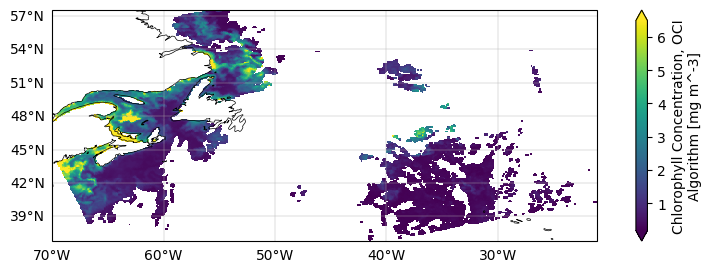

In [28]:
fig, ax = plt.subplots(figsize=(10, 3), subplot_kw={"projection": ccrs.PlateCarree()})
plot = dataset["chlor_a"].plot(x="lon", y="lat", cmap="viridis", robust=True, ax=ax)
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.3)
ax.coastlines(linewidth=0.5)
plt.show()

[back to top](#Contents)

<div class="alert alert-info" role="alert">

You have completed the notebook on using OCCSW to process PACE data! You can now explore more notebooks to learn more about OCSSW usage. 

</div>